# Lesson 19 — Multiple regression (intro)

*Part 2 · Lesson 19 of 20  ·  data: Ames housing*

**←** [Lesson 18: Correlation & regression: inference](18-regression-inference.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  [Lesson 20: The bootstrap & permutation tests](20-bootstrap-permutation.ipynb) **→**

**Same idea, another way:**  [Another dataset →](19-multiple-regression~another-dataset.ipynb)  ·  [The code behind it →](19-multiple-regression~the-code.ipynb)

A single straight line — price from living area — is a good start, but the real world has **many**
knobs at once: a house's price depends on its size *and* its quality *and* its age, all together. In
this lesson we fit **several predictors in one model** and learn the single most important idea in all
of multiple regression: each coefficient is now an **adjusted** effect — the change in price per unit
of *this* predictor **holding the other predictors fixed**.

We'll watch something striking happen: area's "value per square foot" will **drop by half** the moment
we let the model also see quality. That isn't a bug — it's **confounding** (the same trap from the
descriptive *Relationships* lesson) showing up inside a regression. Along the way we'll read a
multiple-regression table, learn why **adjusted $R^2$** exists, slot a **categorical** predictor in as
dummy variables, and meet the gremlin that makes coefficients go haywire: **multicollinearity**. Run
each grey cell with **Shift+Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
sl.use_course_style()

AMES_URL = 'https://www.openintro.org/data/csv/ames.csv'
ames = sl.load_csv('ames.csv', url=AMES_URL)

# statsmodels' formula language doesn't like dots in column names ('Overall.Qual'),
# so give the three predictors we'll use clean, readable names.
ames = ames.rename(columns={'Overall.Qual': 'quality', 'Year.Built': 'year_built'})
ames = ames.dropna(subset=['price', 'area', 'quality', 'year_built'])

print(f'{len(ames):,} homes (Ames, Iowa)')
print('quality is an overall-quality rating from 1 (very poor) to 10 (very excellent).')
ames[['price', 'area', 'quality', 'year_built']].head()

2,930 homes (Ames, Iowa)
quality is an overall-quality rating from 1 (very poor) to 10 (very excellent).


,price,area,quality,year_built
0,215000,1656,6,1960
1,105000,896,5,1961
2,172000,1329,6,1958
3,244000,2110,7,1968
4,189900,1629,5,1997


## 1) From one predictor to many

In the *Relationships* lesson we fit a **simple** regression — one predictor:

$$\hat{y} = b_0 + b_1 x.$$

**Multiple regression** just adds more $x$'s, each with its own slope:

$$\hat{y} = b_0 + b_1 x_1 + b_2 x_2 + b_3 x_3 + \cdots$$

- **The math:** instead of fitting the best *line* through a 2-D cloud, we fit the best *flat sheet*
  (a "plane," or in higher dimensions a "hyperplane") through a multi-dimensional cloud — still by
  **least squares**, still minimizing the sum of squared vertical misses $\sum (y_i - \hat{y}_i)^2$.
- **The meaning:** each $b_j$ is the slope **in its own direction** — how much $\hat{y}$ moves when
  $x_j$ goes up by one unit *and the other predictors stay put*.
- **The interpretation:** that little phrase **"holding the others constant"** is the whole game.
  It lets us ask "what is an extra square foot worth, *comparing homes of the same quality and age*?"
  — a fairer question than the simple model can answer.

We'll use **`smf.ols`** from statsmodels (`ols` = ordinary least squares). You write the model as a
**formula** string, `'y ~ x1 + x2'`, and it does the algebra.

## 2) The baseline: price from area alone

First the familiar one-predictor fit, so we have a number to watch.

In [2]:
model_area = smf.ols('price ~ area', data=ames).fit()

b0 = model_area.params['Intercept']
b1 = model_area.params['area']
print(f'price = {b0:,.0f} + {b1:.2f} * area')
print(f'\nSimple-model slope on area = {b1:.2f} dollars per extra square foot.')
print(f'R-squared = {model_area.rsquared:.3f}  ->  area alone explains '
      f'{model_area.rsquared*100:.0f}% of the variation in price.')

price = 13,290 + 111.69 * area

Simple-model slope on area = 111.69 dollars per extra square foot.
R-squared = 0.500  ->  area alone explains 50% of the variation in price.


So in a one-predictor world, **an extra square foot is "worth" about 112 dollars.** Hold onto that
number — it's about to change.

## 3) Add quality — and watch area's coefficient change

Now we let the model *also* see each home's **quality** rating. We just add `+ quality` to the formula.

In [3]:
model_aq = smf.ols('price ~ area + quality', data=ames).fit()

print('Slope on AREA:')
print(f'   alone:               {model_area.params["area"]:7.2f} dollars / sq ft')
print(f'   controlling quality: {model_aq.params["area"]:7.2f} dollars / sq ft   <- roughly HALVED')
print()
print(f'Slope on QUALITY: {model_aq.params["quality"]:,.0f} dollars per 1-point rating bump')
print(f'\nR-squared jumped from {model_area.rsquared:.3f} to {model_aq.rsquared:.3f}.')

Slope on AREA:
   alone:                111.69 dollars / sq ft
   controlling quality:   58.75 dollars / sq ft   <- roughly HALVED

Slope on QUALITY: 33,241 dollars per 1-point rating bump

R-squared jumped from 0.500 to 0.732.


### Why did area's value drop from ~112 to ~59 dollars?

This is **confounding**, and it's the same lesson as *correlation is not causation* from the
descriptive *Relationships* lesson — now living inside a regression.

Big houses are usually **also** higher quality. So in the simple model, area's slope was secretly
*paid twice*: once for the square footage itself, and once for the **quality that tends to ride along
with size**. The simple slope of 112 was really "size **plus** the quality that comes with size."

When we put `quality` in the model, we let it claim its own share of the credit. What's left for
`area` is the value of square footage **among homes of the same quality** — about **59 dollars**. That
is the *adjusted* effect, and it's the honest answer to "what does an extra square foot add, holding
quality fixed?" Let's confirm the two predictors really do move together.

correlation(area, quality) = 0.57  ->  bigger homes do tend to be higher quality.


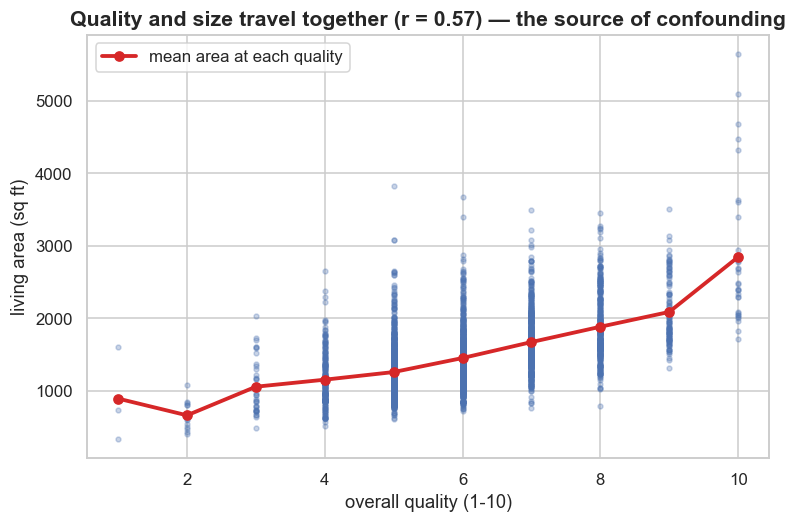

In [4]:
r_area_quality = ames['area'].corr(ames['quality'])
print(f'correlation(area, quality) = {r_area_quality:.2f}  ->  bigger homes do tend to be higher quality.')

fig, ax = plt.subplots()
ax.scatter(ames['quality'], ames['area'], s=10, alpha=0.3, color='#4c72b0')
group_means = ames.groupby('quality')['area'].mean()
ax.plot(group_means.index, group_means.values, color='#d62728', lw=2.5, marker='o',
        label='mean area at each quality')
ax.set_xlabel('overall quality (1-10)'); ax.set_ylabel('living area (sq ft)')
ax.set_title(f'Quality and size travel together (r = {r_area_quality:.2f}) — the source of confounding')
ax.legend(); plt.show()

## 4) Read the full regression table

statsmodels can print the whole story in one table. Let's add the third predictor, **year built**,
and call `.summary()`. It looks busy; we only need a few cells of it, labeled below.

In [5]:
model_full = smf.ols('price ~ area + quality + year_built', data=ames).fit()
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.754
Method:                 Least Squares   F-statistic:                     2992.
Date:                Tue, 09 Jun 2026   Prob (F-statistic):               0.00
Time:                        09:54:47   Log-Likelihood:                -35176.
No. Observations:                2930   AIC:                         7.036e+04
Df Residuals:                    2926   BIC:                         7.038e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.049e+06    5.8e+04    -18.105      0.0

### A guided tour of the numbers that matter

Focus on the **coefficient table** (the middle block) and a couple of fit numbers up top:

- **`coef`** — the slope $b_j$ for each predictor, the *adjusted* effect.
  - `area` ≈ **63** dollars per extra sq ft, *holding quality and age fixed*.
  - `quality` ≈ **26,000** dollars per 1-point quality bump, *holding size and age fixed*.
  - `year_built` ≈ **496** dollars per year newer, *holding size and quality fixed* — a newer home of
    the same size and quality sells for a bit more.
- **`std err`** — the standard error of each slope: how much it would wobble across repeated samples.
  (Smaller is steadier. The *Correlation & regression: inference* lesson builds this idea in full.)
- **`t` and `P>|t|`** — a t-statistic and its **p-value** for the null "this slope is really 0."
  Tiny p-values (`0.000`) say each predictor adds something **beyond** the others.
- **`[0.025  0.975]`** — a 95% **confidence interval** for each slope.
- **`R-squared`** and **`Adj. R-squared`** (top right) — how much of price's variation the model
  explains. That second one is the subject of the next section, and it's the one to trust.

The model now explains about **75%** of the variation in sale price, up from 50% with area alone.

## 5) $R^2$ versus **adjusted** $R^2$ — why the asterisk matters

Plain $R^2$ has a sneaky flaw: **it can never go down when you add a predictor — even a useless one.**
Any new column, however irrelevant, can be twisted to soak up a sliver of leftover variation just by
chance. So "higher $R^2$" is *not* proof that a bigger model is better.

**Adjusted $R^2$** fixes this by charging a **penalty for each predictor**:

$$R^2_{\text{adj}} = 1 - (1 - R^2)\,\frac{n - 1}{\,n - k - 1\,},$$

where $n$ is the number of homes and $k$ is the number of predictors. Add a predictor that pulls its
weight and adjusted $R^2$ rises; add **junk** and it **falls**, because the penalty outweighs the
fluke gain. Let's prove it by tossing a column of **pure random noise** into the model and watching
the two numbers disagree.

In [6]:
rng = np.random.default_rng(21)   # change this seed — the verdict won't change
ames_noise = ames.copy()
ames_noise['random_noise'] = rng.normal(size=len(ames_noise))   # meaningless made-up column

model_junk = smf.ols('price ~ area + quality + year_built + random_noise', data=ames_noise).fit()

print(f'{"":<22}{"plain R^2":>12}{"adjusted R^2":>15}')
print(f'{"3 real predictors":<22}{model_full.rsquared:>12.5f}{model_full.rsquared_adj:>15.5f}')
print(f'{"+ random noise":<22}{model_junk.rsquared:>12.5f}{model_junk.rsquared_adj:>15.5f}')
print('\nPlain R^2 ticked UP (it always does). Adjusted R^2 went DOWN:')
print('the penalty saw through the useless column. Trust the adjusted number.')

                         plain R^2   adjusted R^2
3 real predictors          0.75419        0.75394
+ random noise             0.75419        0.75386

Plain R^2 ticked UP (it always does). Adjusted R^2 went DOWN:
the penalty saw through the useless column. Trust the adjusted number.


**Takeaway:** when you compare models with different numbers of predictors, compare **adjusted $R^2$**,
not plain $R^2$. Plain $R^2$ rewards clutter; adjusted $R^2$ rewards predictors that actually earn
their place.

## 6) A **categorical** predictor — quality as buckets, via dummy variables

So far every predictor was a number. What about a **category** — say "Basic / Standard / Premium"
quality tier? A regression only understands numbers, so a category enters as **dummy variables** (also
called **one-hot** indicators): a 0/1 column for each level. One level is held out as the **baseline**,
and each dummy's coefficient is "how much more (or less) than the baseline."

Let's bucket the 1-10 quality score into three grades and let statsmodels build the dummies for us with
`C(...)` ("treat this as categorical").

In [7]:
ames['quality_grade'] = pd.cut(
    ames['quality'], bins=[0, 4, 7, 10],
    labels=['Basic', 'Standard', 'Premium'])
print('Homes per grade:')
print(ames['quality_grade'].value_counts().reindex(['Basic', 'Standard', 'Premium']).to_string())

model_cat = smf.ols('price ~ area + C(quality_grade)', data=ames).fit()
print('\nCoefficients:')
for name, val in model_cat.params.items():
    print(f'   {name:<32} {val:>12,.0f}')

Homes per grade:
quality_grade
Basic        283
Standard    2159
Premium      488

Coefficients:
   Intercept                              17,197
   C(quality_grade)[T.Standard]           39,533
   C(quality_grade)[T.Premium]           138,763
   area                                       74


### Reading the dummy coefficients

`Basic` is missing from the list on purpose — it's the **baseline** that the others are measured
against. So, **holding area constant**:

- **`C(quality_grade)[T.Standard]`** ≈ **+39,500 dollars** — a Standard-grade home sells for about that
  much more than an otherwise-identical **Basic** home.
- **`C(quality_grade)[T.Premium]`** ≈ **+139,000 dollars** — a Premium home commands a large premium
  over Basic, again for the same square footage.
- **`area`** ≈ **74 dollars** — still the per-sq-ft value, now adjusted for which grade bucket a home
  falls in.

The picture below makes the dummies visible: the categorical model draws **three parallel lines** —
same slope (`area`), shifted up by each grade's coefficient.

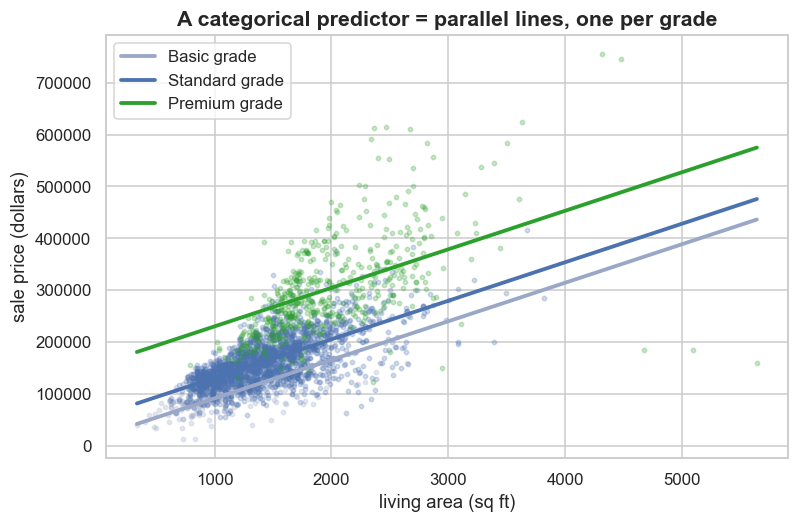

In [8]:
fig, ax = plt.subplots()
grade_colors = {'Basic': '#9aa7c7', 'Standard': '#4c72b0', 'Premium': '#2ca02c'}
area_grid = np.linspace(ames['area'].min(), ames['area'].max(), 50)
for grade, color in grade_colors.items():
    sub = ames[ames['quality_grade'] == grade]
    ax.scatter(sub['area'], sub['price'], s=8, alpha=0.25, color=color)
    pred = model_cat.predict(pd.DataFrame({'area': area_grid, 'quality_grade': grade}))
    ax.plot(area_grid, pred, color=color, lw=2.5, label=f'{grade} grade')
ax.set_xlabel('living area (sq ft)'); ax.set_ylabel('sale price (dollars)')
ax.set_title('A categorical predictor = parallel lines, one per grade')
ax.legend(); plt.show()

## 7) The gremlin: **multicollinearity**

Multiple regression has one notorious failure mode. When two predictors carry **almost the same
information** — they're strongly correlated with *each other* — the model can't tell which one deserves
the credit. The slopes become **wildly unstable**: huge, with giant standard errors, sometimes the
wrong sign entirely. This is **multicollinearity**.

Let's manufacture it on purpose. We'll add a second "area" column that is just living area converted
to **square metres**, plus a whisper of noise — essentially a **duplicate** of `area`. Watch what
happens to area's coefficient and its standard error.

In [9]:
rng = np.random.default_rng(1)
ames_mc = ames.copy()
# area in square metres + tiny noise = almost a carbon copy of 'area'
ames_mc['area_sqm'] = ames_mc['area'] * 0.0929 + rng.normal(0, 0.5, size=len(ames_mc))
print(f"correlation(area, area_sqm) = {ames_mc['area'].corr(ames_mc['area_sqm']):.4f}  <- near-perfect duplicate\n")

clean = smf.ols('price ~ area', data=ames_mc).fit()
collinear = smf.ols('price ~ area + area_sqm', data=ames_mc).fit()

print(f'{"":<26}{"coef":>12}{"std err":>12}')
print(f'{"area (alone)":<26}{clean.params["area"]:>12.1f}{clean.bse["area"]:>12.2f}')
print(f'{"area (+ duplicate)":<26}{collinear.params["area"]:>12.1f}{collinear.bse["area"]:>12.2f}')
print(f'{"area_sqm (+ duplicate)":<26}{collinear.params["area_sqm"]:>12.1f}{collinear.bse["area_sqm"]:>12.2f}')
print('\nThe standard error on area exploded from ~2 to ~200, and the coefficients went haywire')
print('(one even flipped negative). The model literally cannot split the credit between twins.')

correlation(area, area_sqm) = 0.9999  <- near-perfect duplicate

                                  coef     std err
area (alone)                     111.7        2.07
area (+ duplicate)               270.0      195.55
area_sqm (+ duplicate)         -1703.6     2104.48

The standard error on area exploded from ~2 to ~200, and the coefficients went haywire
(one even flipped negative). The model literally cannot split the credit between twins.


### Spotting it: the Variance Inflation Factor (VIF)

You don't have to guess. The **Variance Inflation Factor** measures how much each predictor's variance
is "inflated" by overlap with the others. A rough rule of thumb: **VIF above ~5-10 is a red flag.** Our
three real predictors are fine; the duplicate column lights up like a fire alarm.

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def vif_table(df, cols):
    X = sm.add_constant(df[cols])
    return pd.DataFrame({
        'predictor': cols,
        'VIF': [variance_inflation_factor(X.values, X.columns.get_loc(c)) for c in cols],
    })

print('Healthy model (the three real predictors):')
print(vif_table(ames, ['area', 'quality', 'year_built']).to_string(index=False))
print('\nSick model (area + its near-duplicate):')
print(vif_table(ames_mc, ['area', 'area_sqm']).to_string(index=False))
print('\nVIF all comfortably below ~2.5 = fine.   VIF in the thousands = severe multicollinearity.')

Healthy model (the three real predictors):
 predictor      VIF
      area 1.516843
   quality 2.219242
year_built 1.589691

Sick model (area + its near-duplicate):
predictor         VIF
     area 8957.392611
 area_sqm 8957.392611

VIF all comfortably below ~2.5 = fine.   VIF in the thousands = severe multicollinearity.


**The fix is usually simple:** if two predictors are near-duplicates, **drop one** (or combine them).
Multicollinearity hurts the *individual* coefficients' trustworthiness, not the model's overall
predictions — but since reading the coefficients is the whole point of an intro regression, keep your
predictors from stepping on each other.

## 8) Three cautions before you read too much into a fit

Multiple regression is powerful, which makes it easy to over-claim. Keep three warnings in mind:

1. **It's still not causation.** This is **observational** data — nobody randomly assigned homes their
   quality or age. "Holding quality constant, each sq ft adds ~63 dollars" is an *association among
   comparable homes*, not a promise that **building** an extra square foot adds 63 dollars. Earning the
   word *"causes"* needs a randomized experiment or much heavier machinery (the *Where data comes from*
   lesson explains why).
2. **Extrapolation still bites.** The model learned from homes of 334-5,642 sq ft, quality 1-10, built
   1872-2010. Predicting the price of a 20,000-sq-ft, quality-15 home built in 2100 is pure fantasy —
   the flat sheet knows nothing outside the cloud it was fit to.
3. **Multicollinearity makes coefficients lie.** As we just saw, correlated predictors produce unstable,
   sometimes sign-flipped slopes. Check VIF before trusting any single coefficient.

## Now you try

Predict first, then change a number and re-run:

1. **Reorder the build-up.** In section 3, fit `price ~ quality` *alone* in a new cell, then compare
   `quality`'s slope to its slope in `model_aq` (`price ~ area + quality`). Does quality's coefficient
   *also* shrink once area is controlled for? What does that tell you about which predictor "owns" more
   of the shared credit?

2. **A fourth predictor.** The dataset has many more columns (`ames.columns` lists them). Try adding
   `Lot.Area` after renaming it, e.g.

       ames = ames.rename(columns={'Lot.Area': 'lot_area'})
       smf.ols('price ~ area + quality + year_built + lot_area', data=ames).fit().summary()

   Does **adjusted** $R^2$ go up (lot size earns its place) or down (it's redundant)?

3. **Re-bucket the categorical.** In section 6, change the `pd.cut` bins to four groups, e.g.
   `bins=[0, 3, 5, 7, 10]` with `labels=['Low', 'Mid', 'High', 'Top']`. How many parallel lines does
   the plot draw now, and which level became the baseline (the one missing from the coefficient list)?

4. **Dial the collinearity.** In section 7, raise the noise in `area_sqm` from `rng.normal(0, 0.5, ...)`
   to `rng.normal(0, 50, ...)`. As the duplicate becomes *less* identical, do the standard errors
   calm back down and the VIFs fall out of the danger zone?

## What you learned

- **Multiple regression** fits several predictors at once: $\hat{y} = b_0 + b_1 x_1 + b_2 x_2 + \cdots$,
  still by least squares.
- Each coefficient is an **adjusted** effect — the change in $y$ per unit of *that* predictor
  **holding the others constant** — which is a fairer comparison than a one-predictor slope.
- Adding a correlated predictor can **change** another's coefficient (area's slope roughly halved once
  quality entered): that's **confounding**, the regression face of *correlation is not causation*.
- Read a regression table by its **coefficients** (adjusted slopes), their **p-values** (does each add
  something beyond the rest?), and **adjusted $R^2$** — the fit measure that **penalizes useless
  predictors**, unlike plain $R^2$, which never goes down.
- A **categorical** predictor enters as **dummy (0/1) variables** with one level held out as the
  baseline; the model draws parallel lines shifted by each level's coefficient.
- **Multicollinearity** — predictors carrying nearly the same information — makes coefficients unstable
  and standard errors balloon; spot it with **VIF** (above ~5-10 is trouble) and fix it by dropping or
  combining the overlapping predictors.
- Stay humble: an observational fit shows **association, not causation**, and trusts nothing outside the
  range of the data it learned from.

---

**← Previous:** [Lesson 18: Correlation & regression: inference](18-regression-inference.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Next →:** [Lesson 20: The bootstrap & permutation tests](20-bootstrap-permutation.ipynb)

**Same idea, another way:**  [Another dataset →](19-multiple-regression~another-dataset.ipynb)  ·  [The code behind it →](19-multiple-regression~the-code.ipynb)